In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
### 讀取資料 ###
# df = pd.read_csv("/Users/dimplechang/Desktop/Kaggle Practice/Medical Appointment No Shows/KaggleV2-May-2016.csv")
df = pd.read_csv("KaggleV2-May-2016.csv")

# 理解資料

In [3]:
print(df.head())
print(df.info()) # 看看有沒有缺失值
print(df.describe())

      PatientId  AppointmentID Gender          ScheduledDay  \
0  2.987250e+13        5642903      F  2016-04-29T18:38:08Z   
1  5.589978e+14        5642503      M  2016-04-29T16:08:27Z   
2  4.262962e+12        5642549      F  2016-04-29T16:19:04Z   
3  8.679512e+11        5642828      F  2016-04-29T17:29:31Z   
4  8.841186e+12        5642494      F  2016-04-29T16:07:23Z   

         AppointmentDay  Age      Neighbourhood  Scholarship  Hipertension  \
0  2016-04-29T00:00:00Z   62    JARDIM DA PENHA            0             1   
1  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             0   
2  2016-04-29T00:00:00Z   62      MATA DA PRAIA            0             0   
3  2016-04-29T00:00:00Z    8  PONTAL DE CAMBURI            0             0   
4  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             1   

   Diabetes  Alcoholism  Handcap  SMS_received No-show  
0         0           0        0             0      No  
1         0           0        0      

# 處理資料 #

### 1. 年齡資料
##### 1-1. 偵測到年齡為 -1 之異常值，判定為系統登錄錯誤。考量樣本數充足（N > 110,000），為確保後續統計分析之精確性，採取刪除處理

In [4]:
df = df[df["Age"]>0]

##### 1-2. 年齡分組： Children(0-12), Adolescents(12-18), Young Adults(18-40), Middle Age(30-65), Seniors(65+)

In [5]:
bin = [0, 12, 18, 40, 65, 115]
label = ["Children", "Adolescents", "Young Adults", "Middle Age", "Seniors"]
df["AgeGroup"] = pd.cut(df["Age"], bins=bin, labels=label, right=False) # 新增一欄叫做 AgeGroup #
print(df["AgeGroup"].value_counts()) # 了解各年齡分組人數 #

AgeGroup
Middle Age      36843
Young Adults    31902
Children        16405
Seniors         14397
Adolescents      7435
Name: count, dtype: int64


### 2. 疾病資料
##### 2-1. 轉換殘障數據 Handcap，不在意到底有幾個殘障，改成像 其他 Hipertension DM 一樣，有就是 1 沒有就 0，以方便後續分析 ##

In [6]:
df["Disability"] = np.where(df["Handcap"]>0, 1, 0)

##### 2-2. 增加一個欄位，簡單探討共病

In [7]:
df["Comorbidity"] = df["Hipertension"] + df["Diabetes"] + df["Alcoholism"] + df["Disability"]
print(df["Comorbidity"].value_counts())

Comorbidity
0    80576
1    18122
2     7658
3      618
4       13
Name: count, dtype: int64


### 3. 日期時間資料
##### 3-1. 把 ScheduleDay 和 AppointmentDay 轉換格式

* 先轉換成 datetime 格式之後才可以運算
* 只選出日期的部分「年月日」，時間不需要 > 使用 dt.normalize() 

In [8]:
df["ScheduledDay"] = pd.to_datetime(df["ScheduledDay"]).dt.normalize() # 如果使用 dt.date，資料型態會變轉成物件 object，之後做運算可能會有問題
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"]).dt.normalize()

##### 3-2. 新增一欄為 WaitingDays: 計算出提前預約天數

In [9]:
df["WaitingDays"] = (df["AppointmentDay"] - df["ScheduledDay"]).dt.days # 如果沒有加 dt.days 他會是 datetime 格式，後續不好做運算

# 檢查是否有異常值，WaitingDays 照理說應該都要 >=0
# print(df[df["WaitingDays"] < 0].shape[0]) # shape可以知道符合條件的資料有幾筆，shape[0] 表示列數，shape[1] 表示欄數 

# 有五筆資料的 WaitingDays < 0，因資料量夠大，直接刪除這些異常值，以避免後續統計出問題
df = df[df["WaitingDays"]>=0]
# print(df[df["WaitingDays"] < 0].shape[0]) #再次確認數據

# 了解整體 WaitingDays 數據
print(df["WaitingDays"].describe())

count    106982.000000
mean         10.167290
std          15.263631
min           0.000000
25%           0.000000
50%           4.000000
75%          14.000000
max         179.000000
Name: WaitingDays, dtype: float64


### 4. No-Show 資料：把資料中的 Yes/No，轉換成 1/0，以方便後續運算

In [10]:
df["No_show_binary"] = df["No-show"].map({"Yes":1, "No":0}) 

### EDA 前再次了解資料 

In [11]:
print(df.head())
print(df.info())
print(df.describe())

      PatientId  AppointmentID Gender              ScheduledDay  \
0  2.987250e+13        5642903      F 2016-04-29 00:00:00+00:00   
1  5.589978e+14        5642503      M 2016-04-29 00:00:00+00:00   
2  4.262962e+12        5642549      F 2016-04-29 00:00:00+00:00   
3  8.679512e+11        5642828      F 2016-04-29 00:00:00+00:00   
4  8.841186e+12        5642494      F 2016-04-29 00:00:00+00:00   

             AppointmentDay  Age      Neighbourhood  Scholarship  \
0 2016-04-29 00:00:00+00:00   62    JARDIM DA PENHA            0   
1 2016-04-29 00:00:00+00:00   56    JARDIM DA PENHA            0   
2 2016-04-29 00:00:00+00:00   62      MATA DA PRAIA            0   
3 2016-04-29 00:00:00+00:00    8  PONTAL DE CAMBURI            0   
4 2016-04-29 00:00:00+00:00   56    JARDIM DA PENHA            0   

   Hipertension  Diabetes  Alcoholism  Handcap  SMS_received No-show  \
0             1         0           0        0             0      No   
1             0         0           0       

# Exploratory Data Analysis (EDA) #

### 1. No-show Analysis #
##### 1-1. 整體爽約比例

In [12]:
percentage = df["No_show_binary"].mean() * 100
print("爽約比例：%.2f%%"%percentage)

爽約比例：20.26%


##### 1-2. 爽約和「年齡」有關嗎？

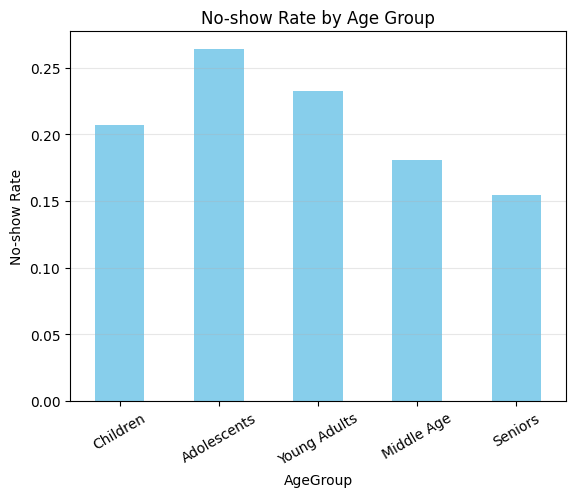

In [13]:
ageGroup_analysis = df.groupby("AgeGroup", observed = False)[["No_show_binary"]].mean()
ageGroup_analysis.plot(
    kind = "bar",
    color = "skyblue",
    rot = 30,
    legend = False # 隱藏圖例讓畫面更乾淨
)
plt.ylabel("No-show Rate")
plt.title("No-show Rate by Age Group")
plt.grid(axis='y', alpha=0.3)
plt.show()

##### 1-3. 爽約和「性別」有關嗎？

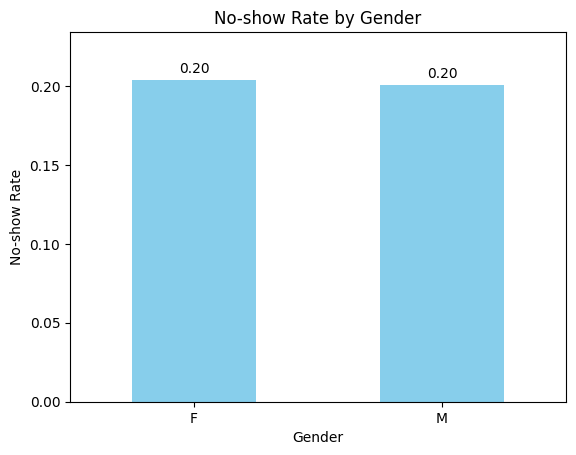

In [14]:
gender_analysis = df.groupby("Gender")[["No_show_binary"]].mean()

# 繪圖並將回傳的容器存入變數 ax
ax = gender_analysis.plot(
    kind = "bar",
    color = "skyblue",
    rot = 0,
    legend = False # 隱藏圖例讓畫面更乾淨
)

# 使用 bar_label 自動標註數值
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3) # padding 是數值與長條頂端的距離，fmt可以設定小數點位數

plt.ylabel("No-show Rate")
plt.title("No-show Rate by Gender")
plt.ylim(0, gender_analysis["No_show_binary"].max() * 1.15) # 稍微拉高 y 軸避免文字被頂掉
plt.show()

##### 1-4. 爽約和「性別 x 年齡層」有關嗎？

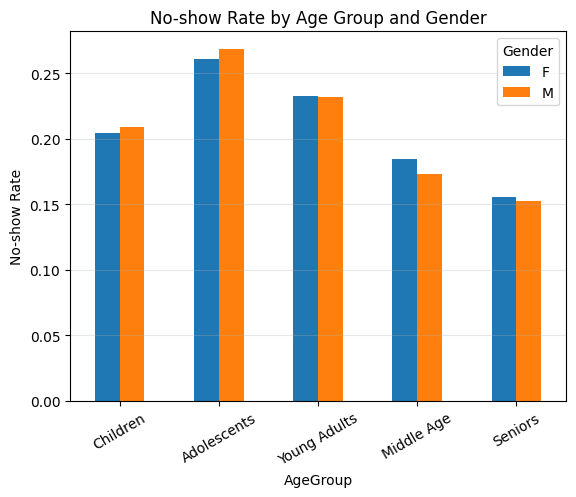

In [15]:
gender_age_analysis = df.pivot_table(index="AgeGroup", columns = "Gender", values = "No_show_binary", aggfunc="mean", observed = False)
gender_age_analysis.plot(
    kind = "bar",
    rot = 30
)
plt.ylabel("No-show Rate")
plt.title("No-show Rate by Age Group and Gender")
plt.grid(axis='y', alpha=0.3)
plt.show()

##### 1-5. 爽約和「waiting days」有關嗎？ ---> 當天才預約的 no-show 比率最低
* 將 WaitingDays 分組: 當天預約、提前 1-3 天、提前 4-7 天、提前 1-2 週、提前 2-4 週、提前一個月以上

             No_show_binary
WaitingDays                
0                  0.046859
1                  0.213803
2                  0.238698
3                  0.236074
4                  0.231965
5                  0.264706
6                  0.246835
7                  0.265622
8                  0.289146
9                  0.274472
10                 0.317647
11                 0.321466
12                 0.314866
13                 0.317509


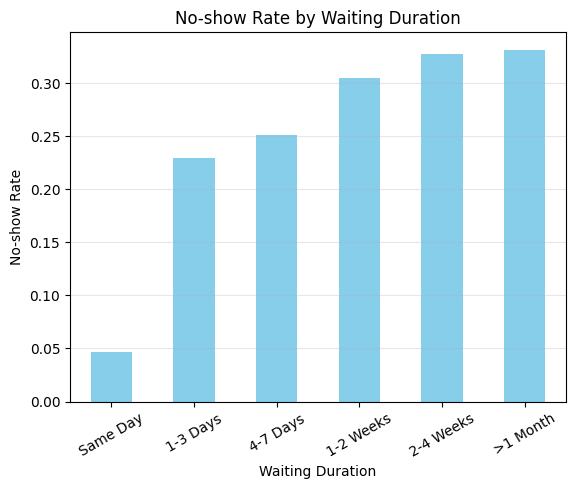

In [16]:
waiting_analysis = df.groupby("WaitingDays")[["No_show_binary"]].mean()
print(waiting_analysis.head(14))

# 將 WaitingDays 分組
bin2 = [0, 1, 4, 8, 15, 31, 180]
label2 = ["Same Day", "1-3 Days", "4-7 Days", "1-2 Weeks", "2-4 Weeks", ">1 Month"]
df["WaitingDays_group"] = pd.cut(df["WaitingDays"], bins=bin2, labels=label2, right=False)

waiting_group_analysis = df.groupby("WaitingDays_group", observed = False)["No_show_binary"].mean()

waiting_group_analysis.plot(
    kind = "bar",
    color = "skyblue",
    rot = 30
)
plt.xlabel("Waiting Duration")
plt.ylabel("No-show Rate")
plt.title("No-show Rate by Waiting Duration")
plt.grid(axis="y", alpha=0.3)
plt.show()

##### 1-6. 爽約和「waiting duration x SMS_received」有關嗎？

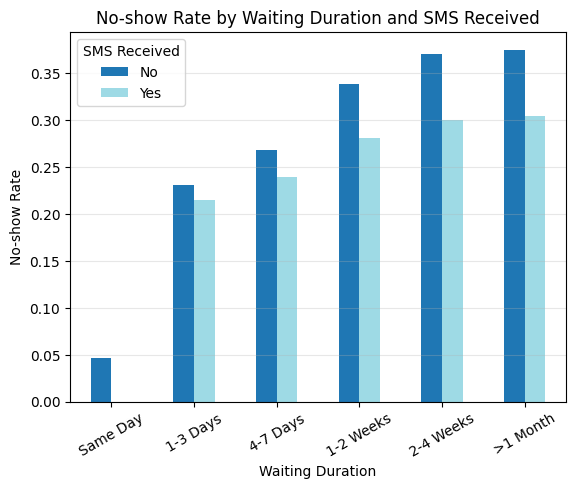

In [17]:
waiting_SMS_analysis = df.pivot_table(index="WaitingDays_group", columns = "SMS_received", values = "No_show_binary", aggfunc="mean", observed = False)
waiting_SMS_analysis.plot(
    kind = "bar",
    rot = 30,
    colormap = "tab20"
)

# 修改圖例：第一個參數是標題，labels 是對應 0 和 1 的文字
plt.legend(title="SMS Received", labels=["No", "Yes"])

plt.xlabel("Waiting Duration")
plt.ylabel("No-show Rate")
plt.title("No-show Rate by Waiting Duration and SMS Received")
plt.grid(axis="y", alpha=0.3)
plt.show()

##### 1-7. 爽約比例和「離的近不近」有關嗎？ --> （沒什麼意義，可能要分組討論)

In [18]:
print(df.groupby("Neighbourhood")[["No_show_binary"]].mean())

                     No_show_binary
Neighbourhood                      
AEROPORTO                  0.125000
ANDORINHAS                 0.231891
ANTÔNIO HONÓRIO            0.175097
ARIOVALDO FAVALESSA        0.227612
BARRO VERMELHO             0.217703
...                             ...
SÃO JOSÉ                   0.217880
SÃO PEDRO                  0.211850
TABUAZEIRO                 0.182571
UNIVERSITÁRIO              0.211921
VILA RUBIM                 0.167672

[81 rows x 1 columns]


### 2. Disease Analysis
##### 2-1. 年齡與疾病數量的關係

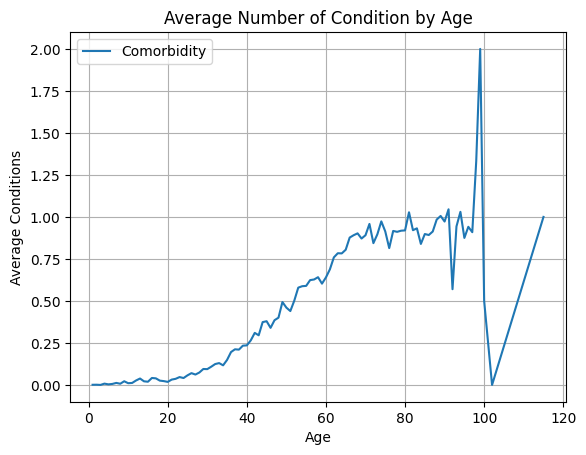

In [19]:
age_Comorbidity_trend = df.groupby("Age", observed = False)[["Comorbidity"]].mean()
age_Comorbidity_trend.plot(
    kind = "line"
)
plt.title("Average Number of Condition by Age")
plt.ylabel("Average Conditions")
plt.grid(True)
# plt.xlim(0, 100)
plt.show()

##### 2-2. 用分組年齡畫圖

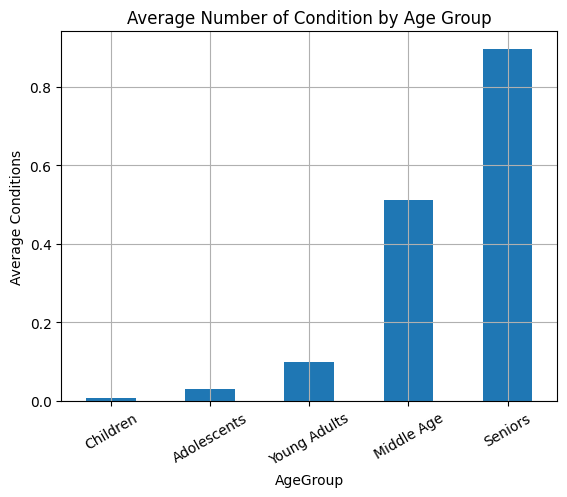

In [20]:
ageGroup_Comorbidity_trend = df.groupby("AgeGroup", observed = False)[["Comorbidity"]].mean()
ageGroup_Comorbidity_trend.plot(
    kind = "bar",
    rot = 30,
    legend = False
)
plt.title("Average Number of Condition by Age Group")
plt.ylabel("Average Conditions")
plt.grid(True)
plt.show()

##### 2-3a.「共病數量 x 年齡」會不會和爽約有關係？

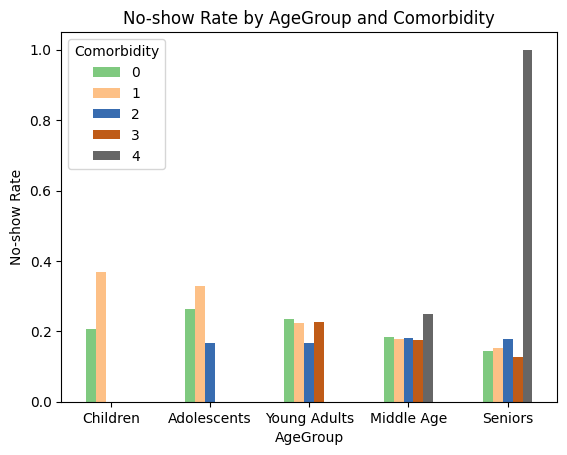

In [21]:
comorbidity_analysis = df.pivot_table(
    index="AgeGroup",
    columns="Comorbidity",
    values="No_show_binary",
    aggfunc="mean",
    observed=False
)

comorbidity_analysis.plot(
    kind = "bar",
    rot = 0,
    colormap = "Accent"
)
plt.title("No-show Rate by AgeGroup and Comorbidity")
plt.ylabel("No-show Rate")
plt.show()

##### 2-3b. 前一個分析在 Seniors 族群中共病症多的族群 no-show 比例特別高，是否有其他原因造成呢？？
* 前面已知 seniors 的 no-show rates 是所有年齡段中最低的，但是慢性病共病最多的 no-show rate 卻很高，是否有其他原因造成呢？？
* 把這群人找出來，看看這群人的 WaitingDays 與爽約的關係

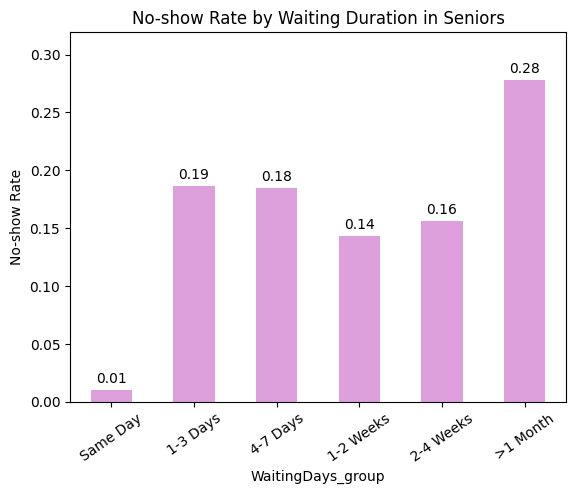

In [22]:
seniors_heavy = df[(df['AgeGroup'] == 'Seniors') & (df['Comorbidity'] >= 3)]
seniors_heavy_analysis = seniors_heavy.groupby("WaitingDays_group", observed = False)[['No_show_binary']].mean()
# print(seniors_heavy_analysis)

ax1 = seniors_heavy_analysis.plot(
    kind = "bar",
    rot = 35,
    color = "plum",
    legend = False # 隱藏圖例讓畫面更乾淨
)

# 使用 bar_label 自動標註數值
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f', padding=3) # padding 是數值與長條頂端的距離，fmt可以設定小數點位數

plt.ylabel("No-show Rate")
plt.title("No-show Rate by Waiting Duration in Seniors")
plt.ylim(0, seniors_heavy_analysis["No_show_binary"].max() * 1.15) 
plt.show()

##### 2-3c. 再加入 SMS_received 資料看看

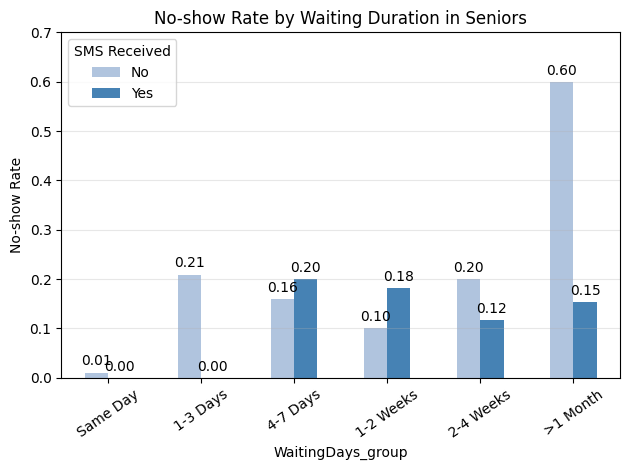

In [26]:
seniors_heavy_SMS_analysis = seniors_heavy.pivot_table(
    index="WaitingDays_group",
    columns="SMS_received", 
    values = "No_show_binary", 
    aggfunc="mean", 
    observed = False
)

ax3 = seniors_heavy_SMS_analysis.plot(
    kind = "bar",
    rot = 35,
    color = ["#B0C4DE", "#4682B4"]
)

for container in ax3.containers:
    ax3.bar_label(container, fmt='%.2f', padding=3)

plt.legend(title = "SMS Received", labels = ["No", "Yes"])
plt.ylabel("No-show Rate")
plt.title("No-show Rate by Waiting Duration in Seniors")
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 0.7)
plt.tight_layout() # 將每張子圖都考量到X、Y軸上的值與標籤， 給予適當的距離
plt.show()